<center><font color='steelblue'> <font size = "5,5">CORPORACIÓN UNIVERSITARIA MINUTO DE DIOS </font></center><br>
<center><font color='steelblue'> <font size = "5">FACULTAD DE INGENIERÍA</font></center><br>
<center><font color='steelblue'> <font size = "4">PROGRAMA INGENIERÍA DE SISTEMAS</font></center><br>
<center><font color='steelblue'> <font size = "3">CURSO BASES DE DATOS MASIVAS</font></center><br>
<center><font color="yellow" size = "4" face = "small fonts">Proyecto Modular - Mojo</font></center>

<center><font color="olive" size = "4" face = "small fonts">DATOS DE LOS PARTICIPANTES DEL GRUPO</font></center>

<font color="yellow" size = "4" face = "small fonts">NRC: </font></center><br>
<font color="yellow" size = "4" face = "small fonts">Nombres: Juan jose Morales Benitez / David Vargas Ramirez </font></center><br>
<font color="yellow" size = "4" face = "small fonts">ID:879302 / 824144 </font></center><br>

<font color="yellow" size = "4" face = "small fonts">El taller retoma algunas de las instrucciones utilizadas a través del curso de Bases de Datos Masivas, tener en cuenta seguir los pasos requeridos.</font></center><br>

<font color="yellow" size = "4" face = "small fonts">Al Cargar los archivos dispuestos en la carpeta Poryecto final BDM se debe utilizar sentencias que no fijen el path, este debe se dinámico en caso de que se creen nuevos paquetes</font></center><br>

<font color="red" size = "4" face = "small fonts">El ejercicio consta de seguir el cuaderno y  realizar las tareas solicitadas, Utilizar y citar la documentación propia de cada una de las herramientas utilizadas para realizar el tratamiento a la data.</font></center><br>

<font color="yellow" size = "4" face = "small fonts">1. Configuración e importe de las librerias.</font></center><br>

In [1]:
# Esta extencion permite que jupyter detecte cambios externos y recargue sin tener que reiniciar VSC
%load_ext autoreload
%autoreload 2


In [2]:
# Importar la librearia os para poder interactuar el sistema donde se esta ejecutando los archivos
import os
import requests
import re
import json
import sqlite3
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from python_on_whales import docker

<font color="yellow" size = "4" face = "small fonts">2. Configure y levante los contenedores necesarios para la actividad, recuerde que la arquitectura respeta a 3 contenedores con una distribucion de DBMongo en cada una de ellas, un contenedor que tiene configurado Mojolicious con todas sus dependencias junto con una base de datos Relacional la cual sera escogida a su gusto.</font></center><br>

In [3]:
# Moverse a la carpeta data donde estan los archivos para lanzar el docker

# Crear y ejecutar el docker-compose.yml
#docker.compose.down()
os.chdir('../data')
docker.compose.build()
docker.compose.up(detach=True)

#1 [internal] load local bake definitions
#1 reading from stdin 602B done
#1 DONE 0.0s

#2 [internal] load build definition from Dockerfile
#2 transferring dockerfile: 1.74kB done
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/ubuntu:22.04
#3 DONE 0.3s

#4 [internal] load .dockerignore
#4 transferring context: 2B done
#4 DONE 0.0s

#5 [1/9] FROM docker.io/library/ubuntu:22.04@sha256:962f6cadeae0ea6284001009daa4cc9a8c37e75d1f5191cf0eb83fe565b63dd7
#5 resolve docker.io/library/ubuntu:22.04@sha256:962f6cadeae0ea6284001009daa4cc9a8c37e75d1f5191cf0eb83fe565b63dd7 0.0s done
#5 DONE 0.0s

#6 [internal] load build context
#6 transferring context: 1.61MB 0.0s done
#6 DONE 0.0s

#7 [3/9] RUN wget -qO - https://www.mongodb.org/static/pgp/server-6.0.asc | apt-key add - &&     echo "deb [ arch=amd64,arm64 ] https://repo.mongodb.org/apt/ubuntu focal/mongodb-org/6.0 multiverse" | tee /etc/apt/sources.list.d/mongodb-org-6.0.list &&     apt-get update &&     apt-get install -y mongodb-

 Network data_default Creating 
 Network data_default Created 
 Container sqlite_db Creating 
 Container mongodb_articulos Creating 
 Container mongodb_ventas Creating 
 Container core_container Creating 
 Container mongodb_personas Creating 
 Container mongodb_articulos Created 
 Container core_container Created 
 Container sqlite_db Created 
 Container mongodb_personas Created 
 Container mongodb_ventas Created 
 Container mongodb_ventas Starting 
 Container sqlite_db Starting 
 Container core_container Starting 
 Container mongodb_articulos Starting 
 Container mongodb_personas Starting 
 Container mongodb_personas Started 
 Container mongodb_articulos Started 
 Container mongodb_ventas Started 
 Container sqlite_db Started 
 Container core_container Started 


<font color="yellow" size = "4" face = "small fonts">3. Una vez tenga el contenedor arriba cargue los datos .Json, uno por cada contenedor DBMongo.</font></center><br>

<font color="yellow" size = "4" face = "small fonts">Tenga en cuenta que debe tener la replica de los formatos `JSon` en cada contenedor</font></center><br>

In [ ]:
# Con estos comandos se deben cargar los datos .json dentro de las mongoDB sin necesidad de una funcion.



# 1. Import Personas
subprocess.run([
    "docker", "exec", "mongodb_personas", 
    "mongoimport", 
    "--username", "root", 
    "--password", "root", 
    "--authenticationDatabase", "admin", 
    "--db", "base_personas", 
    "--collection", "personas", 
    "--file", "/data/db_imports/personas.json", 
    "--jsonArray"
])

# 2. Import Articulos
subprocess.run([
    "docker", "exec", "mongodb_articulos", 
    "mongoimport", 
    "--username", "root", 
    "--password", "root", 
    "--authenticationDatabase", "admin", 
    "--db", "base_articulos", 
    "--collection", "articulos", 
    "--file", "/data/db_imports/articulos.json", 
    "--jsonArray"
])

# 3. Import Ventas
subprocess.run([
    "docker", "exec", "mongodb_ventas", 
    "mongoimport", 
    "--username", "root", 
    "--password", "root", 
    "--authenticationDatabase", "admin", 
    "--db", "base_ventas", 
    "--collection", "ventas", 
    "--file", "/data/db_imports/ventas.json", 
    "--jsonArray"
])

<font color="yellow" size = "4" face = "small fonts">Se debe colocar el puerto expuesto del contenedor `Mojo`, para llamar la función y cargar los datos</font></center><br>

In [4]:
# Cargar data a las Mongo a con la funcion

subprocess.run([
    "curl",
    "http://localhost:8000/load_data"
])


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0

{"message":"All systems loaded"}

100    32  100    32    0     0     19      0  0:00:01  0:00:01 --:--:--    19


CompletedProcess(args=['curl', 'http://localhost:8000/load_data'], returncode=0)

<font color="yellow" size = "4" face = "small fonts">4. Muestre los datos que fueron almacenados en cada una de las distribuciones de BDMongo.</font></center><br>

In [5]:
# Verificar conteo de documentos en la colección personas

#docker exec -it mongodb_ventas mongosh --username root --password root --authenticationDatabase admin

subprocess.run([
    "docker","exec", "mongodb_personas","mongosh",
    "--username", "root", 
    "--password", "root",
    "--authenticationDatabase", "admin",
    "--eval", "db.getSiblingDB('base_personas').personas.countDocuments()"
])

# Verificar conteo de documentos en la colección articulos
subprocess.run([
    "docker","exec", "mongodb_articulos","mongosh",
    "--username", "root", 
    "--password", "root",
    "--authenticationDatabase", "admin",
    "--eval", "db.getSiblingDB('base_articulos').articulos.countDocuments()"
])

# Verificar conteo de documentos en la colección ventas
subprocess.run([
    "docker","exec", "mongodb_ventas","mongosh",
    "--username", "root", 
    "--password", "root",
    "--authenticationDatabase", "admin",
    "--eval", "db.getSiblingDB('base_ventas').ventas.countDocuments()"
])

10000
10000
10000


CompletedProcess(args=['docker', 'exec', 'mongodb_ventas', 'mongosh', '--username', 'root', '--password', 'root', '--authenticationDatabase', 'admin', '--eval', "db.getSiblingDB('base_ventas').ventas.countDocuments()"], returncode=0)

<font color="yellow" size = "4" face = "small fonts">Consultar a tráves del puerto expuesto la data que se encuentran en las colecciones personas, articulos y ventas de DBMongo</font></center><br>

In [2]:
# Ver personas en MongoDB
people = subprocess.run([
    "curl", "http://localhost:8000/mongo/personas"
])




[{"_id":"69e556c2f9966b7fa34b5890","direccion":"8818 Evans Cove Apt. 968, North Hannahville, WY 96152","email":"bondanthony@gmail.com","fechaNacimiento":"1938-05-30","nombres":"Samuel","numeroDocumento":"@10@93@!65","primerApellido":"Roberts","segundoApellido":"Sweeney","telefono":"7546027921"},{"_id":"69e556c2f9966b7fa34b5891","direccion":"9356 Burns Branch, Wardmouth, OK 05932","email":"oliu@hotmail.com","fechaNacimiento":"2016-05-24","nombres":"Aaron","numeroDocumento":"190252420","primerApellido":"Palmer","segundoApellido":"Khan","telefono":"422$9Aq9@1"},{"_id":"69e556c2f9966b7fa34b5892","direccion":"428 Doyle Mountains, Port Annaberg, OH 72608","email":"johnnyramos@gmail.com","fechaNacimiento":"1930-03-29","nombres":"Mary","numeroDocumento":"67q0$A4A1q","primerApellido":"Johnson","segundoApellido":"Gomez","telefono":"2439741404"},{"_id":"69e556c2f9966b7fa34b5893","direccion":"2268 Paul Camp, Michellemouth, NM 29782","email":"jeremy92@gmail.com","fechaNacimiento":"1935-08-09","nomb

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2888  100  2888    0     0  52660      0 --:--:-- --:--:-- --:--:-- 53481


In [7]:
# Ver articulos en MongoDB

subprocess.run([
    "curl","http://localhost:8000/mongo/articulos"
])

[{"_id":"69e51cff19db3f68c98554e6","cantidadArticulo":"35","idArticulo":"358","nombreArticulo":"Intel i9","precioArticulo":301.26},{"_id":"69e51cff19db3f68c98554e7","cantidadArticulo":"13","idArticulo":"267","nombreArticulo":"Kingston HyperX Cloud II","precioArticulo":280.17},{"_id":"69e51cff19db3f68c98554e8","cantidadArticulo":"m18","idArticulo":"T474","nombreArticulo":"SeaSonic Focus Plus","precioArticulo":237.64},{"_id":"69e51cff19db3f68c98554e9","cantidadArticulo":"26","idArticulo":"791","nombreArticulo":"Fractal Design Meshify","precioArticulo":27.47},{"_id":"69e51cff19db3f68c98554ea","cantidadArticulo":"9rJ417","idArticulo":"70","nombreArticulo":"Bose QuietComfort Headphones","precioArticulo":339.93},{"_id":"69e51cff19db3f68c98554eb","cantidadArticulo":"SBB462","idArticulo":"1o834","nombreArticulo":"Sony PlayStation 5","precioArticulo":331.76},{"_id":"69e51cff19db3f68c98554ec","cantidadArticulo":"W957","idArticulo":"238","nombreArticulo":"Razer BlackWidow Keyboard","precioArticul

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1444  100  1444    0     0  14653      0 --:--:-- --:--:-- --:--:-- 14734


CompletedProcess(args=['curl', 'http://localhost:8000/mongo/articulos'], returncode=0)

In [67]:
# Ver ventas en MongoDB
subprocess.run([
    "curl","http://localhost:8000/mongo/ventas"
])

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (7) Failed to connect to localhost port 8000 after 0 ms: Could not connect to server


CompletedProcess(args=['curl', 'http://localhost:8000/mongo/ventas'], returncode=7)

<font color="yellow" size = "4" face = "small fonts">5. Verifique la estructura y tipo de los datos almacenados en las distribuciones DBMongo, genere una ETL para almacenar cada una de las distribuciones en la base de datos Relacional que configuro con anterioridad, recuerde que cada distribucion debe ir en una tabla relacional respetando la integridad referencial.</font></center><br>

In [ ]:

DB_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "almacen.sqlite"))

def limpiar_valor_numerico(valor):
    try:
        if isinstance(valor, str):
            
            valor = re.sub(r'[^0-9.]', '', valor)
        return int(float(valor))
    except (ValueError, TypeError):
        return 0




In [40]:
# ETL ARTICULOS: valida cantidadArticulo y precioArticulo (numéricos), ignora _id
response = requests.get("http://localhost:8000/mongo/articulos/all")
articulos_raw = response.json()

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
cursor.execute('PRAGMA foreign_keys = OFF')

for art in articulos_raw:
    
    id_val = limpiar_valor_numerico(art.get("idArticulo", 0))
    
    cantidad = limpiar_valor_numerico(art.get("cantidadArticulo"))
    precio   = limpiar_valor_numerico(art.get("precioArticulo"))
    
    cursor.execute('''INSERT OR REPLACE INTO articulos 
        (idArticulo, nombreArticulo, cantidadArticulo, precioArticulo)
        VALUES (?, ?, ?, ?)''', 
        (id_val, art.get("nombreArticulo", "Sin nombre"), cantidad, precio)
    )

conn.commit()
conn.close()
print(f"Migrated {len(articulos_raw)} articulos")


Migrated 10000 articulos


In [ ]:
# Obtener datos de MongoDB para personas, escriba un ETL donde haga la validación de numeroDocumento y telefono, asegurando que solo contengan valores 
# numéricos, tener en cuenta elimiar el id que proporciona DBMongo a cada uno de las colecciones para cargarla a la Bases de Datos Relacional en SQLlite que importo.

# ETL PERSONAS: valida numeroDocumento y telefono (solo dígitos), ignora _id de MongoDB
response = requests.get("http://localhost:8000/mongo/personas/all")
personas_raw = response.json()
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
cursor.execute('PRAGMA foreign_keys = OFF')
for p in personas_raw:
    doc = limpiar_valor_numerico(p.get("numeroDocumento"))
    tel = limpiar_valor_numerico(p.get("telefono"))
    
    cursor.execute('''INSERT OR REPLACE INTO personas
        (numeroDocumento, nombres, primerApellido, segundoApellido, email, telefono, direccion, fechaNacimiento)
        VALUES (?,?,?,?,?,?,?,?)''',
        (doc, 
         p.get("nombres",""), 
         p.get("primerApellido",""), 
         p.get("segundoApellido",""), 
         p.get("email",""), 
         tel, 
         p.get("direccion",""), 
         p.get("fechaNacimiento",""))
    )
conn.commit()
conn.close()
print(f"Migrated {len(personas_raw)} personas")

Migrated 10000 personas


In [ ]:
# Obtener datos de MongoDB para ventas
response = requests.get("http://localhost:8000/mongo/ventas/all")
ventas_raw = response.json()

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()


cursor.execute('DELETE FROM ventas')

cursor.execute("SELECT numeroDocumento FROM personas")
ids_personas = set(row[0] for row in cursor.fetchall())

cursor.execute("SELECT idArticulo FROM articulos")
ids_articulos = set(row[0] for row in cursor.fetchall())

ventas_exitosas = 0

for v in ventas_raw:
    id_comprador_raw = v.get("idComprador")
    id_articulo_raw  = v.get("idArticulo")

    try:
        id_comprador = int(id_comprador_raw)
        id_articulo  = int(id_articulo_raw)
    except (ValueError, TypeError):
        continue

    if id_comprador not in ids_personas:
        continue
    if id_articulo not in ids_articulos:
        continue

    cantidad     = limpiar_valor_numerico(v.get("cantidadProductos"))
    precio_total = limpiar_valor_numerico(v.get("precioTotal"))

    try:
        cursor.execute('''INSERT OR REPLACE INTO ventas
            (idVenta, idComprador, idArticulo, cantidadProductos, precioTotal)
            VALUES (?,?,?,?,?)''',
            (limpiar_valor_numerico(v.get("idVenta")),
             id_comprador, id_articulo, cantidad, precio_total))
        ventas_exitosas += 1
    except sqlite3.IntegrityError:
        pass

conn.commit()
conn.close()
print(f"De {len(ventas_raw)} ventas en Mongo, se insertaron {ventas_exitosas} ventas válidas en SQLite.")

De 10000 ventas en Mongo, se insertaron 1391 ventas válidas en SQLite.


<font color="yellow" size = "4" face = "small fonts">6. Muestre la data almacenada en la base de datos Relacional que esta usando, tabla por tabla.</font></center><br>

In [ ]:
# Mostrar data almacenada en la tabla personas
# Conectar a la base de datos SQLite


#docker exec -it sqlite_db sqlite3 /workspace/almacen.sqlite

#sqlite3 /home/juancho/Documents/coding/pandas_stuff/P_SC_MOJO/proyectoSegundoCorteBDM/data/almacen.sqlite 

conexion = sqlite3.connect(DB_PATH)

# Crear una consulta SQL y cargar los resultados en un DataFrame
consulta = "SELECT * FROM personas limit 5;"
df = pd.read_sql_query(consulta, conexion)

# Mostrar los datos
print(df)

# Cerrar la conexión
conexion.close()


   numeroDocumento nombres primerApellido segundoApellido fechaNacimiento  \
0                0   Kevin        Cabrera            Mann      1944-11-04   
1                1   Jerry         Palmer            Hood      1997-03-16   
2                2   Julie         Morgan          Knight      1986-11-12   
3                3    Tara          Mayer            Shaw      2002-10-18   
4                4   Kayla       Stephens          Arroyo      1918-06-07   

     telefono                                          direccion  \
0       78335     2236 Max Junction, West Valeriehaven, AK 92212   
1   808816510                         USNV Spencer, FPO AE 04727   
2       16275  338 Lisa Stravenue Apt. 817, East Christyton, ...   
3  3985112490  679 Dominguez Drives Suite 163, Jaredport, ME ...   
4      127996                   Unit 7213 Box 8436, DPO AP 40175   

                             email  
0           nancymarquez@yahoo.com  
1              jknight@hotmail.com  
2             rho

In [11]:
# Mostrar data almacenada en la tabla articulos
# Conectar a la base de datos SQLite
conexion = sqlite3.connect(DB_PATH)

# Crear una consulta SQL y cargar los resultados en un DataFrame
consulta = "SELECT * from articulos limit 5;"
df = pd.read_sql_query(consulta, conexion)

# Mostrar los datos
print(df)

# Cerrar la conexión
conexion.close()

   idArticulo             nombreArticulo  precioArticulo  cantidadArticulo
0           1  Razer BlackWidow Keyboard           230.0                55
1           2           Deepcool Gammaxx           424.0               840
2           3                AMD Ryzen 7           220.0              8237
3           4        Samsung 970 EVO SSD           355.0                18
4           5   Kingston HyperX Cloud II           351.0                97


In [9]:
# Mostrar data almacenada en la tabla ventas
# Conectar a la base de datos SQLite
conexion = sqlite3.connect(DB_PATH)

# Crear una consulta SQL y cargar los resultados en un DataFrame
consulta = "SELECT * FROM ventas"
df = pd.read_sql_query(consulta, conexion)

# Mostrar los datos
print(df.head(5))

# Cerrar la conexión
conexion.close()

   idVenta  idComprador  idArticulo  cantidadProductos  precioTotal
0        1        61213        2358                  2          202
1        2    731794571         847                  4          877
2        3   8072067084         170                  9          129
3        4   7535211119        2158                 10          315
4        5   5192188378        1763                  5          266


<font color="yellow" size = "4" face = "small fonts">7. Grafique los 5 articulos mas vendidos.</font></center><br>

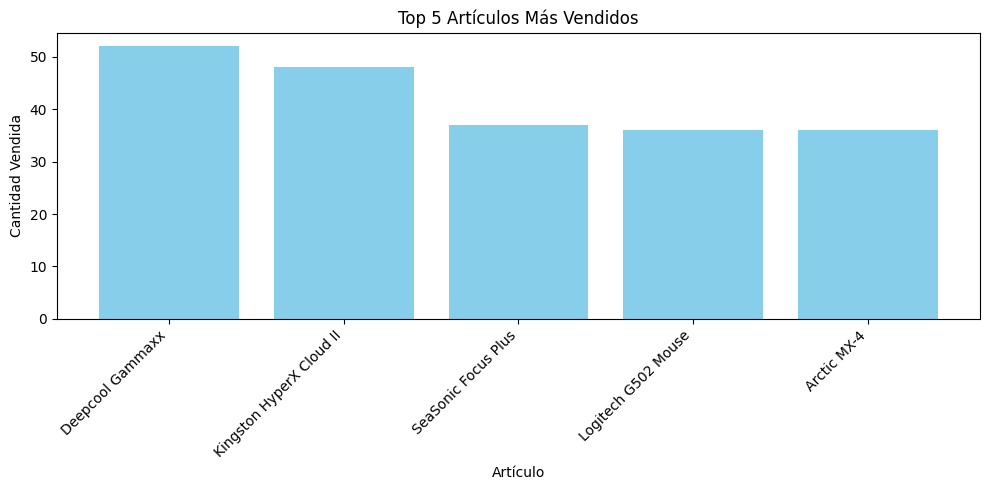

In [43]:
# Conectar a la base de datos
conexion = sqlite3.connect(DB_PATH)

# Ejecutar la consulta y cargar los datos en un DataFrame
consulta = """
    SELECT a.nombreArticulo, COUNT(v.cantidadProductos) AS total_vendido
    FROM ventas v
    JOIN articulos a ON v.idArticulo = a.idArticulo
    GROUP BY a.nombreArticulo  
    ORDER BY total_vendido DESC
    LIMIT 5
"""
df = pd.read_sql_query(consulta, conexion)

# Cerrar la conexión
conexion.close()

# Graficar los datos
plt.figure(figsize=(10, 5))
plt.bar(df['nombreArticulo'], df['total_vendido'], color='skyblue')
plt.ylabel('Cantidad Vendida')
plt.xlabel('Artículo')
plt.title('Top 5 Artículos Más Vendidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<font color="yellow" size = "4" face = "small fonts">8. Grafique los 5 compradores que han realizado más compras.</font></center><br>

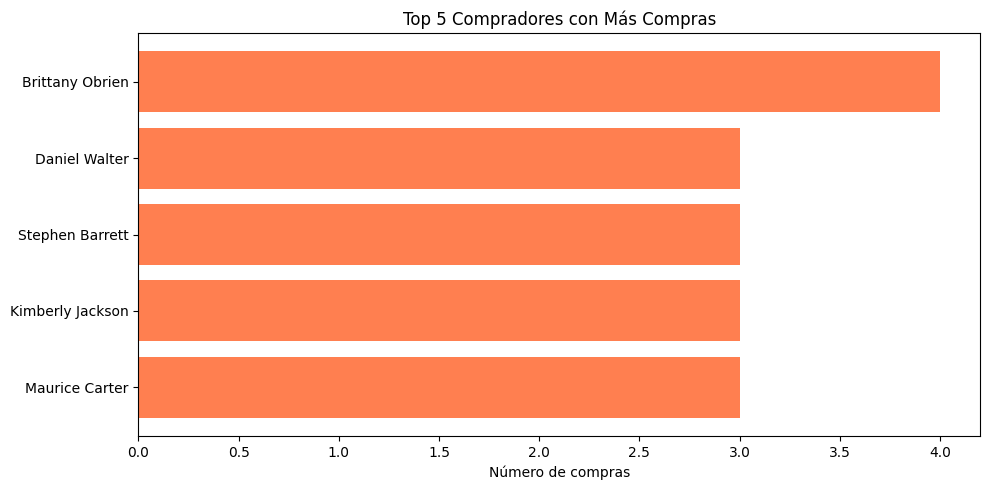

In [44]:
# Conectar a la base de datos
conexion = sqlite3.connect(DB_PATH) 

# Ejecutar la consulta y cargar los datos en un DataFrame
consulta = """
    SELECT p.nombres || ' ' || p.primerApellido AS comprador,
           COUNT(v.idVenta) AS total_compras
    FROM ventas v
    JOIN personas p ON v.idComprador = p.numeroDocumento
    GROUP BY v.idComprador
    ORDER BY total_compras DESC
    LIMIT 5
"""
df = pd.read_sql_query(consulta, conexion)

# Graficar

# Graficar
plt.figure(figsize=(10, 5))
plt.barh(df['comprador'], df['total_compras'], color='coral')
plt.xlabel('Número de compras')
plt.title('Top 5 Compradores con Más Compras')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



<font color="yellow" size = "4" face = "small fonts">9. Grafique la distribución de precios de los 5 primeros artículos .</font></center><br>

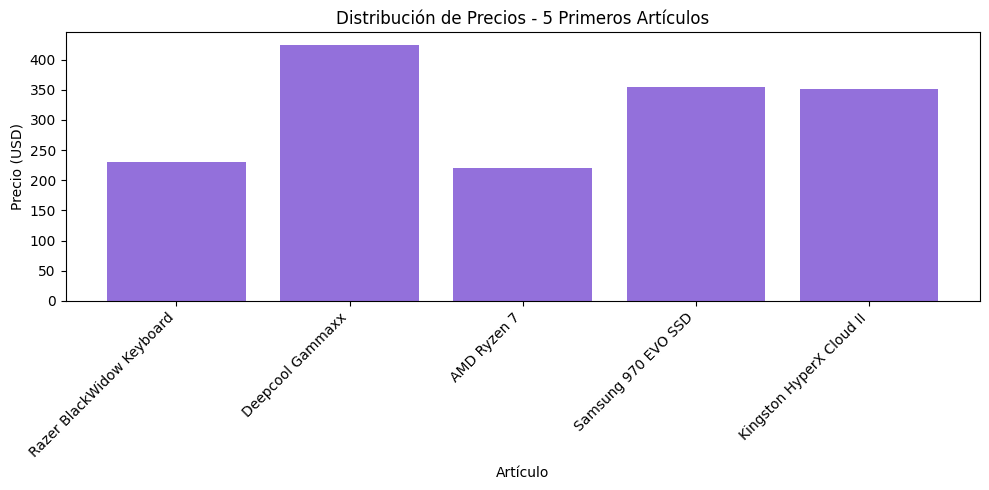

In [45]:
# Conectar a la base de datos
conexion = sqlite3.connect(DB_PATH)

# Ejecutar la consulta y cargar los datos en un DataFrame
consulta = """
    SELECT nombreArticulo, precioArticulo
    FROM articulos
    GROUP BY nombreArticulo
    ORDER BY idArticulo ASC
    LIMIT 5
"""
df = pd.read_sql_query(consulta, conexion)

# Cerrar la conexión
conexion.close()

# Graficar
plt.figure(figsize=(10, 5))
plt.bar(df['nombreArticulo'], df['precioArticulo'], color='mediumpurple')
plt.ylabel('Precio (USD)')
plt.xlabel('Artículo')
plt.title('Distribución de Precios - 5 Primeros Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



<font color="yellow" size = "4" face = "small fonts">10. Grafique los 5 artículos que menos se han vendido.</font></center><br>

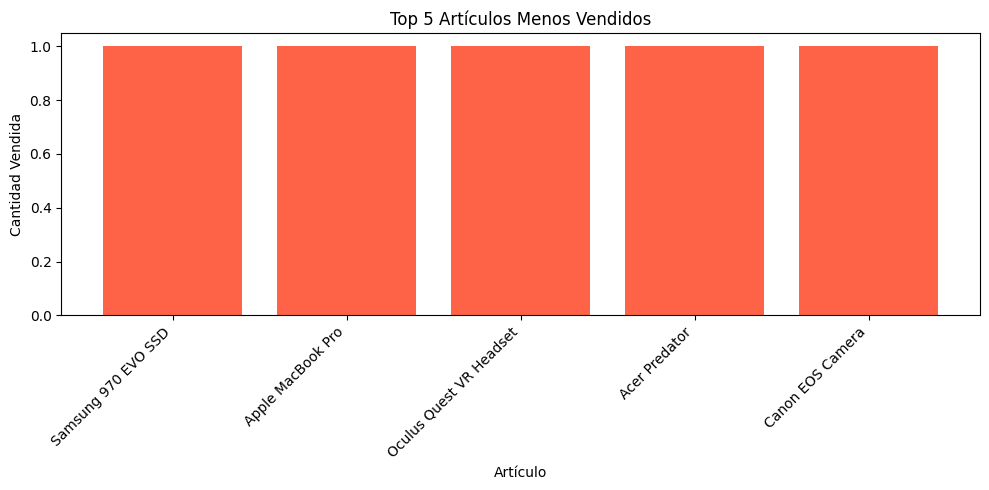

In [46]:
conexion = sqlite3.connect(DB_PATH)

consulta = """
    SELECT nombreArticulo, COUNT(*) as veces_vendido
    FROM ventas v
    JOIN articulos a ON v.idArticulo = a.idArticulo
    GROUP BY v.idArticulo
    ORDER BY veces_vendido ASC
    LIMIT 5;
"""

df = pd.read_sql_query(consulta, conexion)
conexion.close()

plt.figure(figsize=(10, 5))
plt.bar(df['nombreArticulo'], df['veces_vendido'], color='tomato')  # ← aquí el fix
plt.ylabel('Cantidad Vendida')
plt.xlabel('Artículo')
plt.title('Top 5 Artículos Menos Vendidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
